In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from scipy.optimize import minimize


def full_tmdd_ode(t, y, kon, koff, kin, kout, ke_p, ke_l):
  """Definizione delle equazioni differenziali del Full TMDD Model

  (Dua, Hawkins & van der Graaf, 2015)
  """
  L, R, P = y

  # Eq. III.1: Variazione del ligando libero (L)
  dL_dt = -ke_l * L - kon * L * R + koff * P

  # Eq. III.2: Variazione del recettore libero (R)
  dR_dt = kin - kout * R - kon * L * R + koff * P

  # Eq. III.3: Variazione del complesso legato (P)
  dP_dt = kon * L * R - koff * P - ke_p * P

  return [dL_dt, dR_dt, dP_dt]

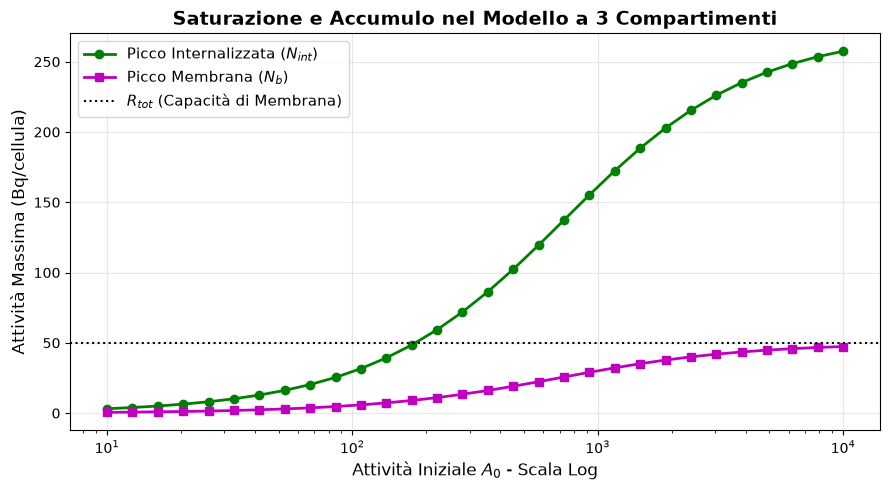

In [2]:
# =============================================================================
# CELLA 2: SATURAZIONE RECETTORIALE (MODELLO A 3 COMPARTIMENTI)
# =============================================================================

A0_range = np.logspace(1, 4, 30) # Da 10 a 10.000
max_internalized = []
max_membrane = []

for A0_val in A0_range:
    sol = solve_ivp(
        tmdd_3comp, (0, 48), [A0_val, 0.0, 0.0], 
        args=(k1_test, k0_test, k2_test, k3_test, Rtot_test), 
        method='RK45'
    )
    max_membrane.append(np.max(sol.y[1]))
    max_internalized.append(np.max(sol.y[2]))

plt.figure(figsize=(9, 5))
plt.plot(A0_range, max_internalized, 'g-o', linewidth=2, label='Picco Internalizzata ($N_{int}$)')
plt.plot(A0_range, max_membrane, 'm-s', linewidth=2, label='Picco Membrana ($N_b$)')
plt.axhline(Rtot_test, color='black', linestyle=':', label='$R_{tot}$ (Capacità di Membrana)')

plt.title('Saturazione e Accumulo nel Modello a 3 Compartimenti', fontsize=14, fontweight='bold')
plt.xlabel('Attività Iniziale $A_0$ - Scala Log', fontsize=12)
plt.ylabel('Attività Massima (Bq/cellula)', fontsize=12)
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

 RISULTATI FIT (FULL TMDD + MM + L DINAMICO)
kon            : 7.218387e-04
koff           : 4.288432e+01
KD (koff/kon)  : 5.940984e+04
kin            : 1.170477e+01
kout           : 9.865377e+00
Rtot all'eq.   : 1.186449e+00
Vmax (int.)    : 9.589274e+01
Km (int.)      : 7.573310e+01
--------------------------------------------------
Chi-quadro Rid : 9.1047


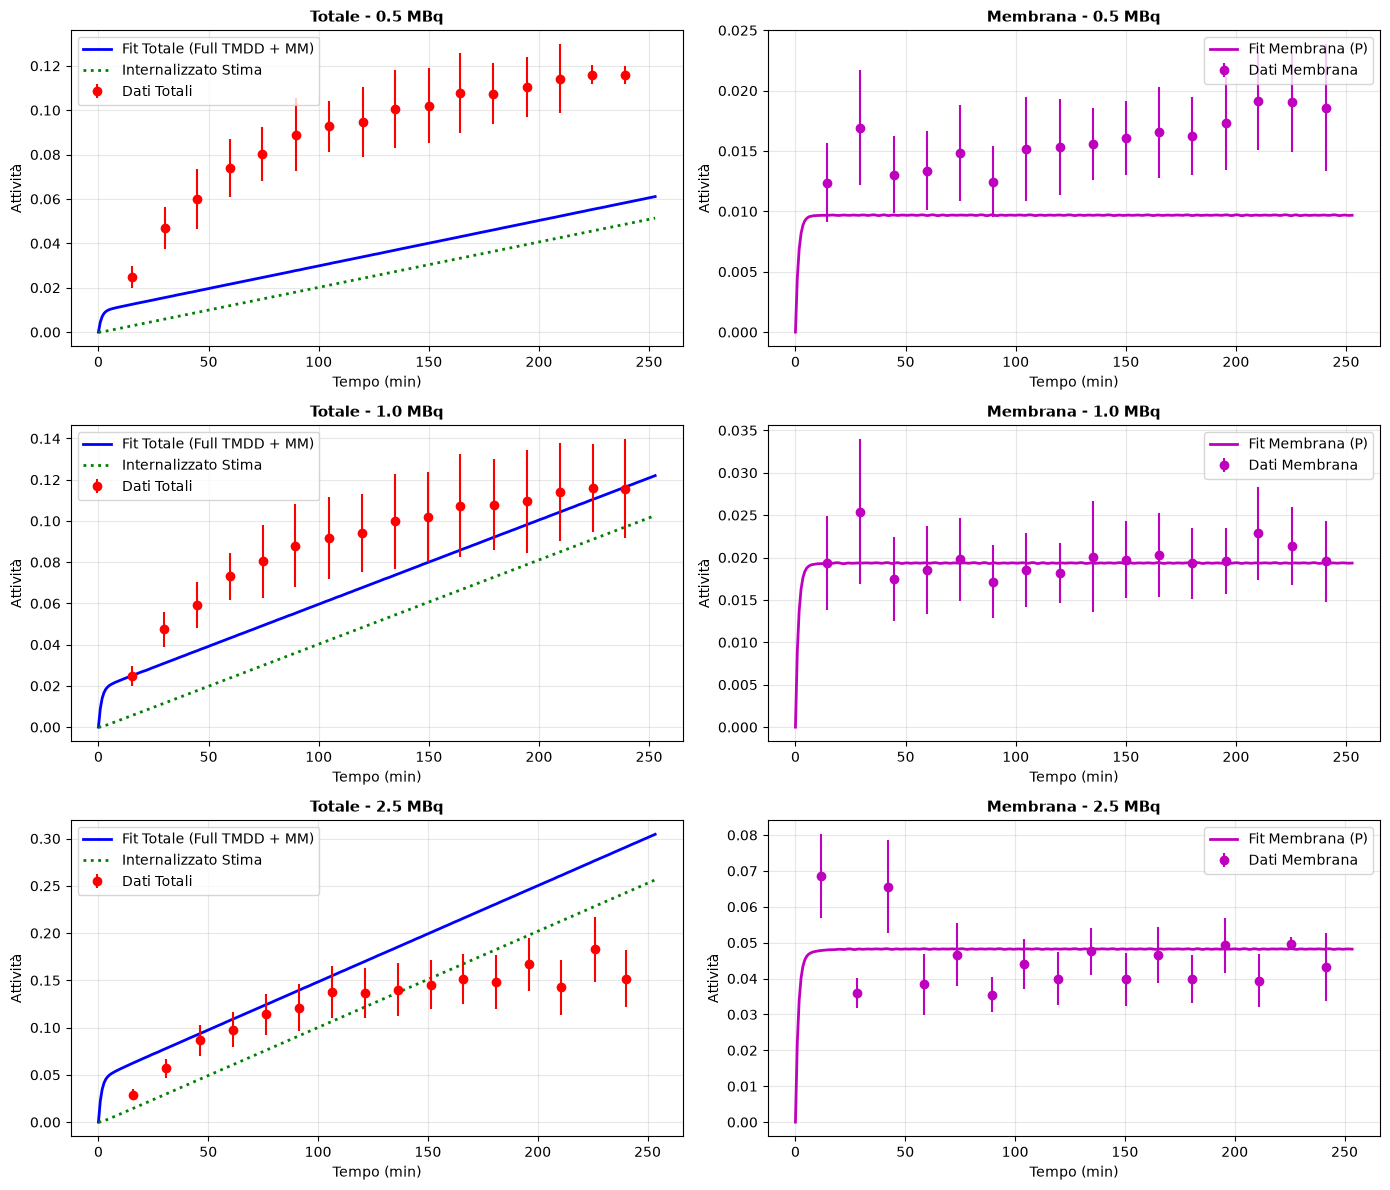

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# =============================================================================
# 1. MODELLO FULL TMDD CON L VARIABILE E MICHAELIS-MENTEN
# =============================================================================
def solve_full_tmdd_mm(params, t_points, A0):
    """
    Full TMDD in vitro:
    - L varia dinamicamente (consumo per legame)
    - Internalizzazione non lineare con Michaelis-Menten (Vmax, Km)
    Parametri: [kon, koff, kin, kout, Vmax, Km]
    """
    kon, koff, kin, kout, Vmax, Km = params

    # Condizioni iniziali
    L0 = A0
    R0 = kin / kout
    P0 = 0.0
    I0 = 0.0

    def ode_system(t, y):
        L, R, P, I = y
        
        L = max(L, 0.0)
        R = max(R, 0.0)
        P = max(P, 0.0)
        I = max(I, 0.0)
        
        # Internalizzazione saturabile (Michaelis-Menten) basata sul complesso P
        v_int = (Vmax * P) / (Km + P) if (Km + P) > 1e-12 else 0.0
        
        # Equazioni TMDD complete (L variabile)
        dL_dt = -kon * L * R + koff * P
        dR_dt = kin - kout * R - kon * L * R + koff * P
        dP_dt = kon * L * R - koff * P - v_int
        dI_dt = v_int
        
        return [dL_dt, dR_dt, dP_dt, dI_dt]

    t_span = (0, float(np.max(t_points)))
    
    # Risolutore ODE veloce grazie a rtol e atol calibrati
    sol = solve_ivp(
        ode_system, t_span, [L0, R0, P0, I0], 
        t_eval=t_points, 
        method='RK45', 
        rtol=1e-3, 
        atol=1e-5
    )

    P_pred = sol.y[2]  # Membrana (P)
    I_pred = sol.y[3]  # Internalizzato (I)
    
    A_mem_pred = P_pred
    A_tot_pred = P_pred + I_pred  # Totale cellulare

    return A_mem_pred, A_tot_pred

def global_residuals_full_mm(params, datasets):
    all_residuals = []
    for exp in datasets:
        A0 = exp['A0']
        
        # Residui sul totale
        _, pred_tot = solve_full_tmdd_mm(params, exp['t_exp_tot'], A0)
        res_tot = (pred_tot - exp['y_tot_exp']) / exp['err_tot']
        
        # Residui sulla membrana
        pred_mem, _ = solve_full_tmdd_mm(params, exp['t_exp_mem'], A0)
        res_mem = (pred_mem - exp['y_mem_exp']) / exp['err_mem']
        
        all_residuals.extend(res_tot)
        all_residuals.extend(res_mem)
        
    return np.array(all_residuals)

# =============================================================================
# 2. ESECUZIONE DEL FIT GLOBALE (6 parametri)
# =============================================================================
p0           = [1e-4, 0.1,  10.0, 0.05, 5.0,  50.0]
lower_bounds = [1e-8, 1e-4, 1e-2, 1e-4, 1e-3, 1.0]
upper_bounds = [1.0,  50.0, 1e4,  10.0, 1e3,  1e4]

res_fit = least_squares(
    global_residuals_full_mm, 
    p0, 
    bounds=(lower_bounds, upper_bounds),
    args=(exp_data,),
    method='trf',
    loss='soft_l1',
    f_scale=1.0
)

kon_f, koff_f, kin_f, kout_f, Vmax_f, Km_f = res_fit.x
KD_f = koff_f / kon_f
Rtot_eq = kin_f / kout_f

# Statistica
N_tot_points = len(res_fit.fun)
p_num = len(res_fit.x)
dof = N_tot_points - p_num
chi2 = np.sum(res_fit.fun**2)
chi2_red = chi2 / dof if dof > 0 else 1.0

print("==================================================")
print(" RISULTATI FIT (FULL TMDD + MM + L DINAMICO)")
print("==================================================")
print(f"kon            : {kon_f:.6e}")
print(f"koff           : {koff_f:.6e}")
print(f"KD (koff/kon)  : {KD_f:.6e}")
print(f"kin            : {kin_f:.6e}")
print(f"kout           : {kout_f:.6e}")
print(f"Rtot all'eq.   : {Rtot_eq:.6e}")
print(f"Vmax (int.)    : {Vmax_f:.6e}")
print(f"Km (int.)      : {Km_f:.6e}")
print("--------------------------------------------------")
print(f"Chi-quadro Rid : {chi2_red:.4f}")
print("==================================================")

# =============================================================================
# 3. GRAFICI DI VERIFICA
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, exp in enumerate(exp_data):
    A0 = exp['A0']
    t_max_eval = max(np.max(exp['t_exp_tot']), np.max(exp['t_exp_mem'])) * 1.05
    t_smooth_h = np.linspace(0, t_max_eval, 300)
    
    pred_mem_smooth, pred_tot_smooth = solve_full_tmdd_mm(res_fit.x, t_smooth_h, A0)
    pred_int_smooth = pred_tot_smooth - pred_mem_smooth
    t_smooth_min = t_smooth_h * 60.0

    # Totale
    ax_tot = axes[idx, 0]
    ax_tot.errorbar(exp['t_min_tot'], exp['y_tot_exp'], yerr=exp['err_tot'], fmt='ro', label='Dati Totali', zorder=5)
    ax_tot.plot(t_smooth_min, pred_tot_smooth, 'b-', linewidth=2, label='Fit Totale (Full TMDD + MM)')
    ax_tot.plot(t_smooth_min, pred_int_smooth, 'g:', linewidth=2, label='Internalizzato Stima')
    ax_tot.set_title(f"Totale - {exp['label']}", fontsize=11, fontweight='bold')
    ax_tot.set_xlabel('Tempo (min)', fontsize=10); ax_tot.set_ylabel('Attività', fontsize=10)
    ax_tot.grid(True, alpha=0.3); ax_tot.legend(frameon=True)

    # Membrana
    ax_mem = axes[idx, 1]
    ax_mem.errorbar(exp['t_min_mem'], exp['y_mem_exp'], yerr=exp['err_mem'], fmt='mo', label='Dati Membrana', zorder=5)
    ax_mem.plot(t_smooth_min, pred_mem_smooth, 'm-', linewidth=2, label='Fit Membrana (P)')
    ax_mem.set_title(f"Membrana - {exp['label']}", fontsize=11, fontweight='bold')
    ax_mem.set_xlabel('Tempo (min)', fontsize=10); ax_mem.set_ylabel('Attività', fontsize=10)
    ax_mem.grid(True, alpha=0.3); ax_mem.legend(frameon=True)

plt.tight_layout()
plt.show()